#### Exercise 1 - Starter - Correlation v Causation

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.formula.api as smf


## Correlation vs Causation

Many observed associations between variables may indicate correlation rather than causation.

Observing below monthly average revenue per member by membership status, it looks like members are spending a lot more then non-members. A campaign manager may then decide to run a campaign to get more users to sign up, as that should increase our revenue. But is that true? The above reasoning is based on correlation. In causal inference world, we should ask the question: is the difference in spending caused by loyalty program, or is a loyalty program member just different to begin with? 

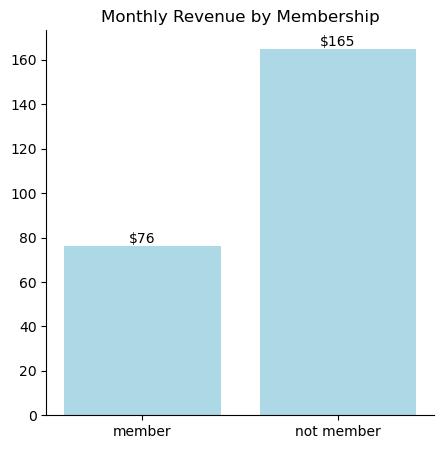

In [2]:
rev = [76, 165]
labels=['member', 'not member']

plt.figure(figsize=(5,5))
bars = plt.bar(labels, rev,color='lightblue')

for bar in bars:
    height=bar.get_height()
    plt.text(
        bar.get_x()+bar.get_width()/2,
        height,
        '$'+str(height),
        ha='center',
        va='bottom'
    )

ax=plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.title('Monthly Revenue by Membership')
plt.show()

## Example of introducing counfounding factor 'Loyalty status' in Revenue analysis

- We first create data of affinity score, representing how much customer like the brand from 1 to 100
- Then we create the sign up status as indiction if they are member or not
- We then create a formula of revenue where it's only depending on the affinity score, and the sign up status doesn't matter
- Then we prove the sign up status as confounding factor for revenue as correlation but not causation by running a two sample t tests vs linear regression

In [3]:
# Set random seed for reproducibility
np.random.seed(42)

# Number of users
n_users = 2000

# 1. Affinity score (1 to 100): How much does the customer inherently like the product or platform?
affinity = np.random.uniform(1, 100, size=n_users)

# Original sigmoid function
def sigmoid(x):
    return 1 / (1 + np.exp(-0.1 * (x - 50)))

loyalty_signup_probability = sigmoid(affinity)

# 3. Sign-up assignment (1 = signed up, 0 = did not)
loyalty_signup = np.random.binomial(1, loyalty_signup_probability)


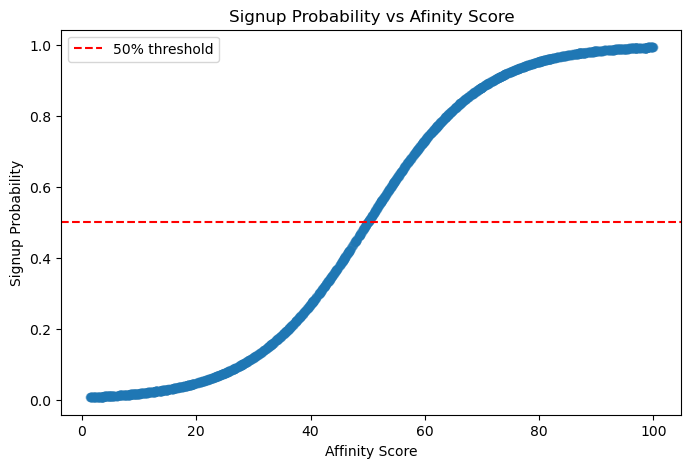

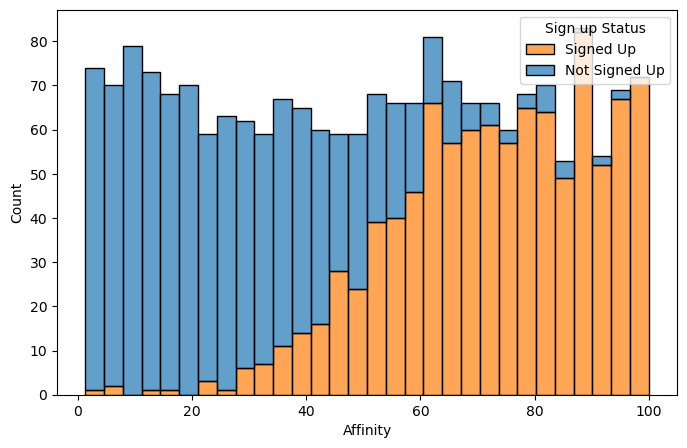

In [4]:
# TO-DO: plot signup rate probability against affinity scores  
plt.figure(figsize=(8,5))

plt.scatter(affinity, loyalty_signup_probability, alpha=0.3)
plt.xlabel('Affinity Score')
plt.ylabel('Signup Probability')
plt.axhline(0.5, color='red', linestyle='--', label='50% threshold')
plt.title('Signup Probability vs Afinity Score')
plt.legend()
plt.show()

# TO-DO: Plot the distribution of signup rates against affinity scores 

df = pd.DataFrame({
    "affinity": affinity,
    "signup": loyalty_signup
})

plt.figure(figsize=(8,5))
sns.histplot(data=df,x='affinity', hue='signup', bins=30, alpha=0.7, multiple='stack')
plt.xlabel('Affinity')
plt.ylabel('Count')
plt.legend(loc='upper right', title='Sign up Status', labels=['Signed Up', 'Not Signed Up'])
plt.show()

**Observation:**
- as it shows, the higher the affinity score, the higher chance that the customer is a loyalty member. This is expected, as we created the sign up status based on affinity score. These two variables are correlated.
- the frequency count also validates that, the affinity score on either side clusters more 'signed up' vs 'non-signed up' member counts

In [5]:

# Generate Customer Revenue as linear function of affinity and signup status 
# Base revenue + boost for affinity + any boost for status + random noise

impact_affinity = 2 # incremental revenue per affinity point 
impact_loyalty_signup = 0 # no additional revenue boost for loyalty signup in this case
monthly_revenue = 20 + impact_affinity * affinity + impact_loyalty_signup * loyalty_signup + np.random.normal(0, 5, size=n_users)


# TO-DO: Build DataFrame using affinity, loyalty_signup, and monthly_revenue. View data summary using describe()
data = pd.DataFrame({
    'affinity': affinity,
    'signup': loyalty_signup,
    'monthly_revenue': monthly_revenue
})

data.describe()

,affinity,signup,monthly_revenue
count,2000.000000,2000.000000,2000.000000
mean,50.365056,0.496000,120.637667
std,28.928869,0.500109,57.949341
min,1.318608,0.000000,11.938210
25%,24.566601,0.000000,69.600268
50%,51.227776,0.000000,122.772926
75%,75.317204,1.000000,170.574529
max,99.972050,1.000000,227.589025


- Here we create the monthly revenue by having affinity factor with weight of 2, and the loyalty status with a weight of 0, i.e. this factor doesn't matter. 

In [6]:
# TO-DO: Describe mean and standard deviation of revenue and affinity by loyalty signup status
data.groupby(['signup'])[['affinity', 'monthly_revenue']].agg(['mean', 'std'])

affinity            monthly_revenue           
             mean        std            mean        std
signup                                                 
0       28.229194  18.935288       76.494752  38.126882
1       72.857948  17.858846      165.492564  36.065414

- As it shows, a loylaty customer contribute revenue for about \\$165, while the non-loyal one is about \\$76. So the loyalty status is strongly correlated to the revenue contribution. Same as the affiity score as well.

In [7]:
# TO-DO: Calculate and print the revenue gap (difference in average revenue) by signup status 
gap = data.groupby('signup')['monthly_revenue'].mean().diff().iloc[1]
print(f'Difference of Signed up vs non-Signed up: ${gap:.2f}')
# TO-DO: t-test for the difference in monthly revenue using scipy.stats.ttest_ind 

a=data[data['signup']==0]['monthly_revenue']
b=data[data['signup']==1]['monthly_revenue']
result = stats.ttest_ind(a, b, alternative='two-sided',equal_var=False)
print(f'P value of two sample t tests: {result.pvalue}')

Difference of Signed up vs non-Signed up: $89.00
P value of two sample t tests: 0.0


- When conducting the two sample t tests from these two status group, it's statistically significant. Based on this result. Should we conclude that the revenue contribution is caused by the loyalty status? In the contrary, we already know that the revenue is created by 2 x affinity and 0 x loyalty status

In [8]:
# TO-DO: Estimate linear Regression of revenue on affinity and loyalty status using statsmodels.formula.api.ols 

formula = 'monthly_revenue~affinity+C(signup)'
model = smf.ols(formula = formula , data=data).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:        monthly_revenue   R-squared:                       0.992
Model:                            OLS   Adj. R-squared:                  0.992
Method:                 Least Squares   F-statistic:                 1.314e+05
Date:                Fri, 28 Nov 2025   Prob (F-statistic):               0.00
Time:                        09:43:54   Log-Likelihood:                -6069.4
No. Observations:                2000   AIC:                         1.214e+04
Df Residuals:                    1997   BIC:                         1.216e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         20.1019      0.235     85.

- With the linear regression model, we can see the intercept coefficient is close to 20, and the coefficients of each predictor are also aligned with our original formula: affinity is closed to 2, sign up is closed to 0. The model shows a 0.99 R-squared, almost explaining 100% of the variances in the response variable. The P values of Intercept and Affinity coefficients are less than 0.01, hence they are significant in predicting the revenue, while the signup status doesn't, as this is our confounding factor to begin with.

In [9]:
# But we don't observe affinity directly, we only observe signup status.
# TO-DO Regression of revenue on signup status without affinity as a control 
formula = 'monthly_revenue~C(signup)'
model = smf.ols(formula = formula , data=data).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:        monthly_revenue   R-squared:                       0.590
Model:                            OLS   Adj. R-squared:                  0.590
Method:                 Least Squares   F-statistic:                     2874.
Date:                Fri, 28 Nov 2025   Prob (F-statistic):               0.00
Time:                        09:43:54   Log-Likelihood:                -10065.
No. Observations:                2000   AIC:                         2.013e+04
Df Residuals:                    1998   BIC:                         2.015e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         76.4948      1.169     65.

But we didn't ask for affinity score. We only have the sign up status, and here after removing affinity score, our model's predictability shrinks immediately from 0.99 to 0.59, but it shows a biased significant impact of loyalty signup (P value ~0) on revenue.

This is the same result that we saw in the t-test and just by comparing the differences in means between loyalty sign-up groups. Hence, the loyalty sign-up group is a confounding variable. We know the ground truth that it should be zero. But when we estimate this model without controling for affinity, we get a highly biased result.

## Conclusion

While correlations can provide valuable insights, they do not necessarily indicate that one variable **causes** changes in another. It's important to control for confounding variables to avoid biased results in causal inference.